In [1]:
#
#
#

import arslabrobotics as ar
import numpy as np

data = np.loadtxt("ball_data.txt")

regression_matrix = []
Y = []

(rows, cols) = data.shape

for i in range(3, rows):
    u = data[i-1, 0]
    y = data[i, 1]
    y_1 = data[i-1, 1]
    y_2 = data[i-2, 1]
    y_3 = data[i-3, 1]
    regression_matrix.append( [-y_3 , -y_2, -y_1, u ])
    Y.append( [ y ])

regression_matrix = np.array(regression_matrix)
Y = np.array(Y)

print("Regression Matrix:", regression_matrix)

reg_inv = np.linalg.pinv(regression_matrix)

params = reg_inv @ Y

error = Y - regression_matrix @ params

print("Error vector:", error)

a = params[:3]
b = params[3]

Regression Matrix: [[-2.38418579e-07 -2.38418579e-07 -0.00000000e+00  5.00000000e+02]
 [-2.38418579e-07 -0.00000000e+00 -1.66668177e-01  5.00000000e+02]
 [-0.00000000e+00 -1.66668177e-01 -3.33056450e-01  5.00000000e+02]
 ...
 [-9.81586075e+01 -9.81616898e+01 -9.81647644e+01  5.00000000e+02]
 [-9.81616898e+01 -9.81647644e+01 -9.81678391e+01  5.00000000e+02]
 [-9.81647644e+01 -9.81678391e+01 -9.81709061e+01  5.00000000e+02]]
Error vector: [[-0.35440405]
 [-0.14657553]
 [-0.05502646]
 ...
 [ 0.01357808]
 [ 0.01358275]
 [ 0.01358207]]


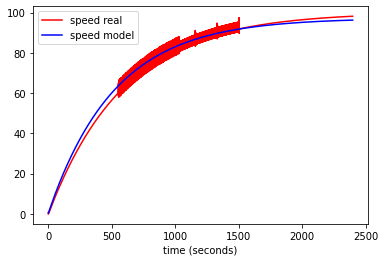

In [2]:
dp = ar.data.DataPlotter()
dp.set_x("time (seconds)")
dp.add_y("speed_r", "speed real")
dp.add_y("speed_m", "speed model")

system = ar.identification.ARXModel(a, b)
t = 0
for i in range(rows):
    u = data[i, 0]
    y = system.evaluate(u)
    dp.append_x(t)
    dp.append_y("speed_m", y)
    dp.append_y("speed_r", data[i,1])
    t += 1

dp.plot()
